In [1]:
import pandas as pd
import numpy as np

In [30]:
dt_rzd = pd.read_csv('/Users/rus.r.aliev/Desktop/pa model/SMADIMO-GP-2/data/_api/processed_rzd.csv')

In [80]:
dt_avia = pd.read_csv('/Users/rus.r.aliev/Desktop/pa model/SMADIMO-GP-2/data/_api/to_export.csv')

In [32]:
dt_rzd['days_in_road'] = np.ceil(dt_rzd['minutes_in_road'] / 60 / 24).astype(int)

In [33]:
date_budni = ['2026-06-01', '2026-06-02', '2026-06-03', '2026-06-04', '2026-06-05', '2026-06-08', '2026-06-09', '2026-06-10', '2026-06-11', '2026-06-12', '2026-06-15', '2026-06-16', '2026-06-17', '2026-06-18', '2026-06-19', '2026-06-22', '2026-06-23', '2026-06-24', '2026-06-25', '2026-06-26', '2026-06-29', '2026-06-30']

date_vih = ['2026-06-06', '2026-06-07', '2026-06-13', '2026-06-14', '2026-06-20', '2026-06-21', '2026-06-27', '2026-06-28']

In [79]:
dt_rzd['date_budni'] = dt_rzd['date'].isin(date_budni).astype(int)

# Хотим посмотреть если человек получает 4 тысячи за командировку в какие города ему выгоднее ехать на поезде, а в какие на самолёте

In [ ]:
# Сравниваем цены в будни и в выходные москва - город прибытия - времени в пути(считаем за рабочий день если меньше одного дня(24 часов), округлили в большую сторону) - плацкарт/купе - будни/выходные 
dt_rzd['itog_price'] = np.ceil(dt_rzd['wagon_price'] + 4000*dt_rzd['days_in_road']).astype(int)
dt_avia['value_itog'] = np.ceil(dt_avia['value'] + 4000).astype(int)

/var/folders/5p/c7c6ph0564v8r79g0vn5l0940000gq/T/ipykernel_1575/1437695694.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_price_by_city, x='city', y='itog_price', palette='viridis')


Text(0.5, 0, 'Город')

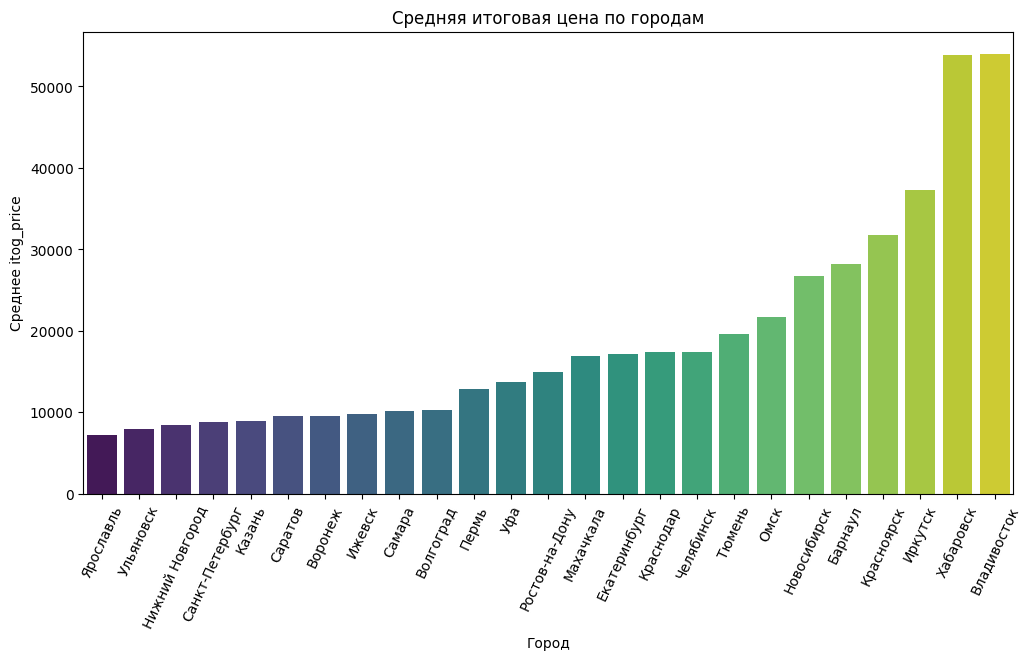

In [115]:
import matplotlib.pyplot as plt
import seaborn as sns
avg_price_by_city = dt_rzd.loc[dt_rzd['wagon_type']=='Купе'].groupby('city', as_index=False)['itog_price'].mean()
avg_price_by_city = avg_price_by_city.sort_values('itog_price')
plt.figure(figsize=(12, 6))
sns.barplot(data=avg_price_by_city, x='city', y='itog_price', palette='viridis')
plt.ylabel('Среднее itog_price')
plt.xticks(rotation=65)
plt.title('Средняя итоговая цена по городам')
plt.xlabel('Город')


/var/folders/5p/c7c6ph0564v8r79g0vn5l0940000gq/T/ipykernel_1575/1450697148.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_price_by_city, x='city', y='itog_price', palette='viridis')


Text(0.5, 0, 'Город')

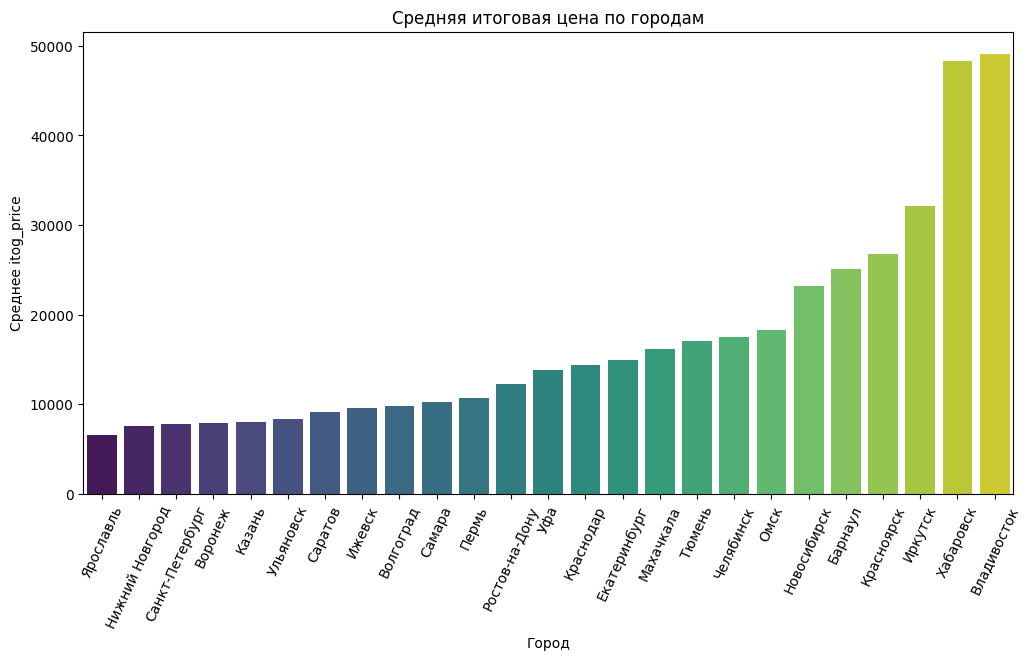

In [114]:
import matplotlib.pyplot as plt
import seaborn as sns
avg_price_by_city = dt_rzd.loc[dt_rzd['wagon_type']=='Плацкарт'].groupby('city', as_index=False)['itog_price'].mean()
avg_price_by_city = avg_price_by_city.sort_values('itog_price')
plt.figure(figsize=(12, 6))
sns.barplot(data=avg_price_by_city, x='city', y='itog_price', palette='viridis')
plt.ylabel('Среднее itog_price')
plt.xticks(rotation=65)
plt.title('Средняя итоговая цена по городам')
plt.xlabel('Город')


In [84]:
dt_rzd_agg = dt_rzd.groupby(['city','date_budni', 'wagon_type','train_id'])['itog_price'].mean().reset_index()

In [85]:
dt_rzd_agg.loc[dt_rzd_agg['city']=='Барнаул']

,city,date_budni,wagon_type,train_id,itog_price
0,Барнаул,0,Купе,№ 078Ы,29570.769231
1,Барнаул,0,Купе,№ 096Н,26473.000000
2,Барнаул,0,Плацкарт,№ 078Ы,25389.076923
3,Барнаул,0,Плацкарт,№ 096Н,24769.200000


In [86]:
dt_rzd_agg_2 = dt_rzd_agg.groupby(['city', 'wagon_type'])['itog_price'].min().reset_index()
dt_rzd_agg_2 = dt_rzd_agg_2.loc[dt_rzd_agg_2['wagon_type'].isin(['Купе','Плацкарт'])]

In [87]:
dt_merge = dt_rzd_agg_2.merge(dt_avia, left_on='city',right_on='name', how='inner')

/var/folders/5p/c7c6ph0564v8r79g0vn5l0940000gq/T/ipykernel_1575/1126803996.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=grouped, x='city', y='diff', palette='coolwarm')


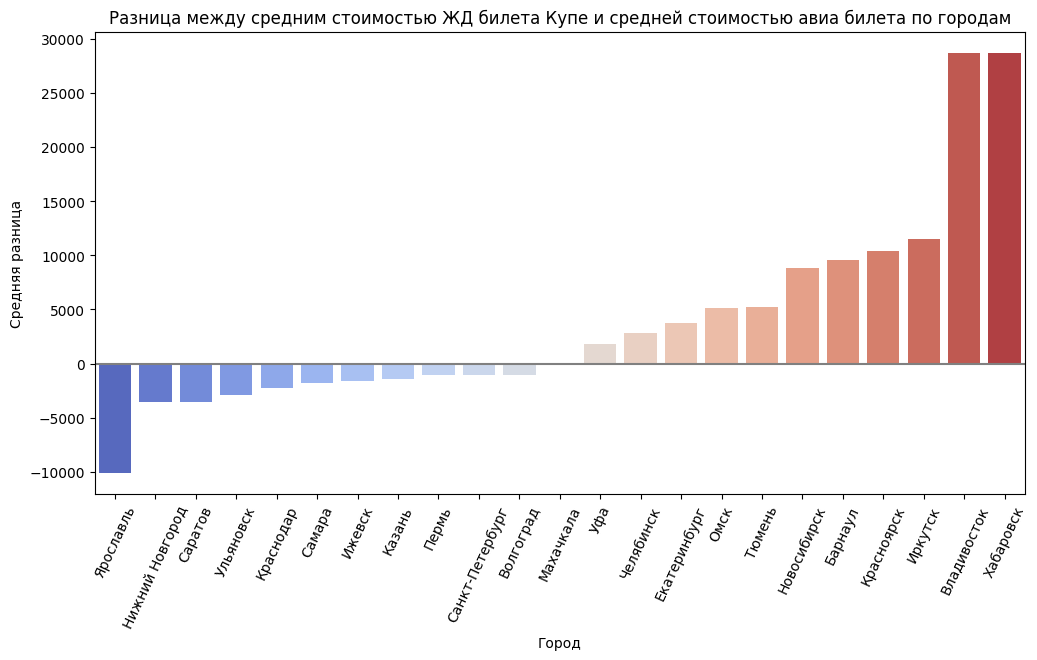

In [111]:
grouped = dt_merge.loc[dt_merge['wagon_type']=='Купе'].groupby('city').agg(
    mean_itog_price=('itog_price', 'mean'),
    mean_value=('value_itog', 'mean')
)
grouped['diff'] = grouped['mean_itog_price'] - grouped['mean_value']
grouped = grouped.sort_values('diff')
plt.figure(figsize=(12, 6))
sns.barplot(data=grouped, x='city', y='diff', palette='coolwarm')
plt.ylabel('Средняя разница')
plt.xlabel('Город')
plt.xticks(rotation=65)
plt.axhline(0, color='gray')  
plt.title('Разница между средним стоимостью ЖД билета Купе и средней стоимостью авиа билета по городам')
plt.show()

/var/folders/5p/c7c6ph0564v8r79g0vn5l0940000gq/T/ipykernel_1575/585347082.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=grouped, x='city', y='diff', palette='coolwarm')


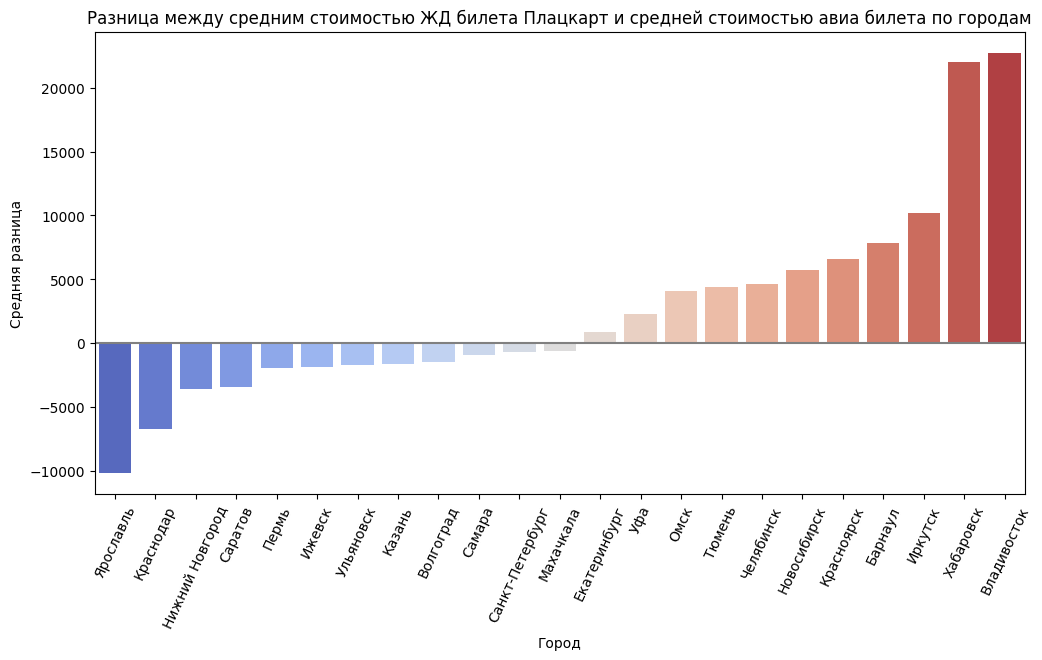

In [109]:
grouped = dt_merge.loc[dt_merge['wagon_type']=='Плацкарт'].groupby('city').agg(
    mean_itog_price=('itog_price', 'mean'),
    mean_value=('value_itog', 'mean')
)
grouped['diff'] = grouped['mean_itog_price'] - grouped['mean_value']
grouped = grouped.sort_values('diff')
plt.figure(figsize=(12, 6))
sns.barplot(data=grouped, x='city', y='diff', palette='coolwarm')
plt.ylabel('Средняя разница')
plt.xlabel('Город')
plt.xticks(rotation=65)
plt.axhline(0, color='gray')  
plt.title('Разница между средним стоимостью ЖД билета Плацкарт и средней стоимостью авиа билета по городам')
plt.show()